# Semana 3 — Equação de Schrödinger Dependente do Tempo

Nesta semana você encontrará a primeira **equação diferencial parcial** do curso.

A ideia computacional central será o **método das linhas**:

$$
\boxed{
\text{EDP}
\xrightarrow{\text{discretizar o espaço}}
\text{sistema de EDOs}
\xrightarrow{\texttt{solve\_ivp}}
\text{evolução temporal}
}
$$

No final da aula, você utilizará esse método para medir a transmissão de um pacote de onda através de uma barreira quântica.

> Como nas semanas anteriores, os blocos marcados com `TODO` são as partes que você deve construir.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation

from IPython.display import HTML

## Lição 1 — A equação de Schrödinger dependente do tempo

Usaremos

$$
i\frac{\partial\psi}{\partial t}
=
-\frac12\frac{\partial^2\psi}{\partial x^2}
+
V(x)\psi,
$$

ou

$$
\frac{\partial\psi}{\partial t}
=
\frac{i}{2}\frac{\partial^2\psi}{\partial x^2}
-iV(x)\psi.
$$

Agora a incógnita é uma função de **posição e tempo**,

$$
\psi(x,t).
$$

Ao discretizar o espaço, representaremos essa função por muitos valores

$$
\psi_1(t),\psi_2(t),\ldots,\psi_N(t).
$$

O tempo continuará sendo tratado pelo integrador do SciPy.

### Antes de programar

Responda oralmente com sua dupla:

1. O que representa $|\psi(x,t)|^2$? R: Densidade de probabilidade, que remete à chance de encontrar determinada partícula em posição $x$ em um instante $t$ no tempo.
2. Qual variável será discretizada por nós? R: Será o espaço, portanto, a variável $x$ que o representa.
3. Qual variável continuará sendo integrada pelo `solve_ivp`? R: O tempo $t$.

## Lição 2 — Derivadas espaciais numéricas

A derivada segunda será aproximada por

$$
f''(x_i)
\simeq
\frac{f_{i+1}-2f_i+f_{i-1}}{\Delta x^2}.
$$

Antes de colocar essa aproximação dentro da equação de Schrödinger, vamos testá-la em

$$
f(x)=\sin x,
$$

para a qual sabemos que

$$
f''(x)=-\sin x.
$$

Usaremos uma malha periódica. Por isso, observe o uso de `endpoint=False`.

In [9]:
N_teste = 200

x_teste = np.linspace(
    -np.pi,
    np.pi,
    N_teste,
    endpoint=False
)

dx_teste = x_teste[1] - x_teste[0]

# TODO 1:
# construa f(x) = sin(x)

f = np.sin(x_teste)

# TODO 2:
# calcule numericamente a derivada segunda usando np.roll

d2f_num = ( np.roll(f, -1) - 2*f + np.roll(f, 1) ) / (dx_teste**2)

# solução exata
d2f_exata = -np.sin(x_teste)

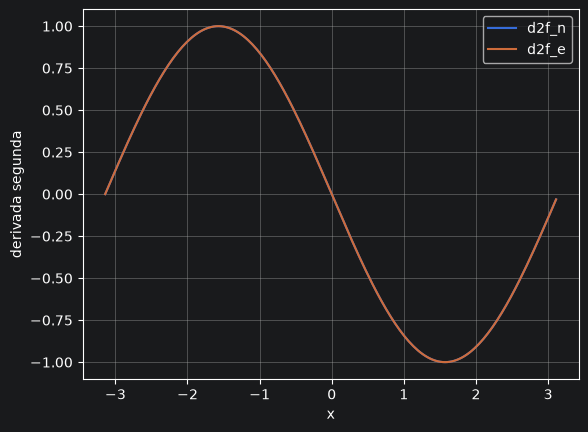

In [10]:
plt.figure()

# TODO 3:
# coloque a derivada numérica e a exata no mesmo gráfico

plt.plot(x_teste, d2f_num, label='d2f_n')
plt.plot(x_teste, d2f_exata, label='d2f_e')

plt.xlabel("x")
plt.ylabel("derivada segunda")
plt.legend()
plt.grid()
plt.show()

In [11]:
# TODO 4:
# Meça o maior erro absoluto da aproximação.

erro_maximo = np.max(np.abs(d2f_exata-d2f_num))

print("Maior erro =", erro_maximo)

Maior erro = 8.224399765777157e-05


### Condição de contorno

`np.roll` faz o último ponto conversar com o primeiro.

Portanto, a discretização acima utiliza **condições periódicas de contorno**.

Nas simulações desta aula usaremos uma região grande o suficiente para que o pacote de onda não alcance as bordas durante o intervalo de interesse.

## Lição 3 — O método das linhas

Vamos agora construir a malha utilizada na equação de Schrödinger.

Escolheremos

$$
-40 \leq x < 40.
$$

A equação discretizada será

$$
\frac{d\psi_i}{dt}
=
\frac{i}{2}
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2}
-iV_i\psi_i.
$$

In [12]:
xmin = -40.0
xmax = 40.0
N = 300

x = np.linspace(
    xmin,
    xmax,
    N,
    endpoint=False
)

dx = x[1] - x[0]

print("dx =", dx)

dx = 0.2666666666666657


In [16]:
def schrodinger(t, psi, V, dx):

    # TODO 5:
    # calcule psi_xx com diferenças finitas e np.roll

    d2psi = (np.roll(psi, -1) - 2*psi + np.roll(psi, 1))

    # TODO 6:
    # escreva a equação de Schrödinger isolando dpsi/dt

    dpsi_dt = (1j/2) * (d2psi / (dx**2)) - 1j*V*psi

    return dpsi_dt

### O que acabou de acontecer?

Antes tínhamos uma EDP para $\psi(x,t)$.

Depois da discretização espacial, `psi` é um vetor contendo $N$ valores.

A função `schrodinger` devolve então $N$ derivadas temporais.

É exatamente isso que o `solve_ivp` precisa para integrar um grande sistema de EDOs.

## Lição 4 — Propagação de um pacote de onda

Começaremos com uma partícula livre,

$$
V(x)=0.
$$

A condição inicial será um pacote gaussiano,

$$
\psi(x,0)
=
A
\exp\left[
-\frac{(x-x_0)^2}{4\sigma^2}
\right]
e^{ik_0x}.
$$

Usaremos inicialmente

$$
x_0=-18,
\qquad
\sigma=2.5,
\qquad
k_0=2.
$$

In [17]:
def pacote_gaussiano(x, x0, sigma, k0):

    # TODO 7:
    # construa o pacote gaussiano complexo

    A = 1
    psi = A * np.exp(-(((x-x0)**2)/(4*(sigma**2)))) * np.exp(1j * k0 * x)

    # TODO 8:
    # calcule a norma contínua

    norma = np.sqrt(np.sum(np.abs(psi)**2) * dx) #Soma de Riemann

    # TODO 9:
    # normalize a função de onda

    psi = psi / norma

    return psi

# Alternativamente, pensei em usar "return psi/norma" a fim de evitar duas funções chamadas psi

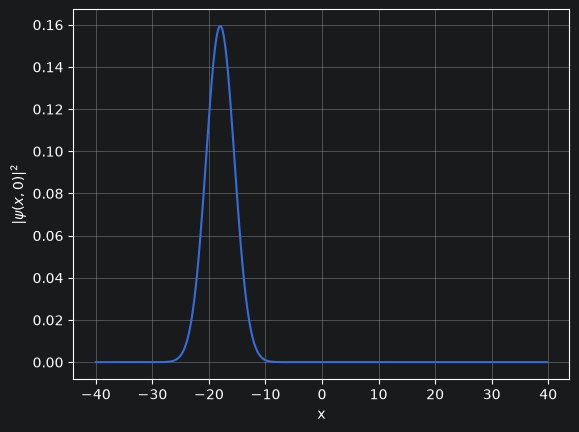

Probabilidade inicial = 1.0000000000000036


In [18]:
x0 = -18.0
sigma = 2.5
k0 = 2.0

psi0 = pacote_gaussiano(
    x,
    x0,
    sigma,
    k0
)

# partícula livre
V_livre = np.zeros_like(x)

plt.figure()
plt.plot(x, np.abs(psi0)**2)
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,0)|^2$")
plt.grid()
plt.show()

print(
    "Probabilidade inicial =",
    np.trapezoid(np.abs(psi0)**2, x=x) #regra do trapézio
)

In [19]:
tf_livre = 10.0
tempos_livre = np.linspace(0, tf_livre, 180)

sol_livre = solve_ivp(
    schrodinger,
    [0, tf_livre],
    psi0,
    t_eval=tempos_livre,
    args=(V_livre, dx),
    method="DOP853",
    rtol=1e-6,
    atol=1e-8
)

# Cada linha de psi_t corresponde a um instante.
psi_t_livre = sol_livre.y.T

print("Formato da solução:", psi_t_livre.shape)

Formato da solução: (180, 300)


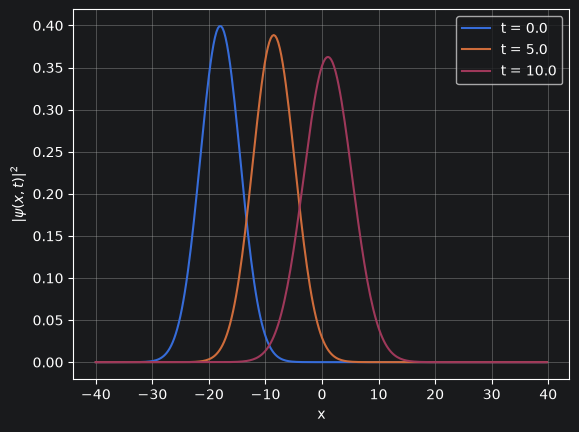

In [21]:
plt.figure()

# TODO 10:
# Escolha três instantes da solução e represente |psi|^2.
# Sugestão: início [0], aproximadamente metade [89~90] e final [-1].

plt.plot(x, np.abs(psi_t_livre[0]), label=f"t = {tempos_livre[0]:.1f}" )
plt.plot(x, np.abs(psi_t_livre[89]), label=f"t = {tempos_livre[89]:.1f}" )
plt.plot(x, np.abs(psi_t_livre[-1]), label=f"t = {tempos_livre[-1]:.1f}" )

plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t)|^2$")
plt.legend()
plt.grid()
plt.show()

### Observe

O pacote se desloca para a direita e também modifica sua forma.

Nesta aula não mediremos detalhadamente o espalhamento do pacote. Ele será usado principalmente como uma partícula incidente sobre uma barreira.

## Lição 5 — Probabilidade e animação

A probabilidade total é

$$
P(t)
=
\int |\psi(x,t)|^2\,dx.
$$

Para uma evolução quântica fechada esperamos

$$
P(t)\simeq1.
$$

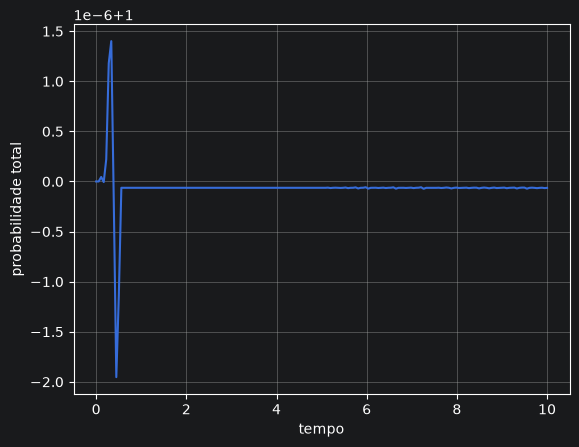

Maior desvio de P=1: 1.9534183113290027e-06


In [24]:
# TODO 11:
# Calcule P(t) para todos os instantes.
# psi_t_livre tem formato: [tempo, posição]

probabilidade = np.sum(np.abs(psi_t_livre)**2, axis=1) * dx

plt.figure()
plt.plot(tempos_livre, probabilidade)
plt.xlabel("tempo")
plt.ylabel("probabilidade total")
plt.grid()
plt.show()

print(
    "Maior desvio de P=1:",
    np.max(np.abs(probabilidade - 1))
)

### Animação

A infraestrutura gráfica é fornecida. Conecte cada quadro à densidade de probabilidade correspondente.

In [ ]:
densidades_livre = np.abs(psi_t_livre)**2

fig, ax = plt.subplots(figsize=(8, 4))

linha, = ax.plot([], [], linewidth=2)

ax.set_xlim(xmin, xmax)
ax.set_ylim(0, 1.1*np.max(densidades_livre))

ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi(x,t)|^2$")

titulo = ax.set_title("")


def atualizar_livre(i):

    # TODO 12:
    # atualize a curva usando a densidade no instante i

    linha.set_data(...)

    titulo.set_text(
        f"t = {tempos_livre[i]:.2f}"
    )

    return linha,


animacao_livre = FuncAnimation(
    fig,
    atualizar_livre,
    frames=len(tempos_livre),
    interval=35,
    blit=True
)

plt.close(fig)

HTML(animacao_livre.to_jshtml())

## Lição 6 — Colocando uma barreira no caminho

Agora mudaremos apenas o potencial.

Considere

$$
V(x)=
\begin{cases}
V_0, & |x|<a/2,\\
0, & |x|\geq a/2.
\end{cases}
$$

Usaremos inicialmente

$$
V_0=3,
\qquad
a=1.5.
$$

O método das linhas e o integrador permanecerão exatamente os mesmos.

In [6]:
def barreira_retangular(x, V0, a):

    V = np.zeros_like(x)

    # TODO 13:
    # atribua V0 aos pontos que estão dentro da barreira

    ...

    return V

In [7]:
V0 = 3.0
a = 1.5

V = barreira_retangular(
    x,
    V0,
    a
)

plt.figure()
plt.plot(x, V)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.xlim(-8, 8)
plt.grid()
plt.show()

NameError: name 'x' is not defined

In [ ]:
# Vamos escolher uma energia característica abaixo da barreira.

E_inc = 2.0

# TODO 14:
# usando E = k0^2/2, calcule k0

k0 = ...

psi0_barreira = pacote_gaussiano(
    x,
    x0,
    sigma,
    k0
)

# O tempo final foi escolhido para que o espalhamento já tenha ocorrido,
# mas os pacotes ainda não tenham alcançado as bordas periódicas.

tf = 30.0/k0
tempos = np.linspace(0, tf, 220)

sol_barreira = solve_ivp(
    schrodinger,
    [0, tf],
    psi0_barreira,
    t_eval=tempos,
    args=(V, dx),
    method="DOP853",
    rtol=1e-6,
    atol=1e-8
)

psi_t = sol_barreira.y.T
densidades = np.abs(psi_t)**2

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

linha, = ax.plot([], [], linewidth=2)

ax.axvspan(
    -a/2,
    a/2,
    alpha=0.2
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(0, 1.1*np.max(densidades))

ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi(x,t)|^2$")

titulo = ax.set_title("")


def atualizar_barreira(i):

    linha.set_data(
        x,
        densidades[i]
    )

    titulo.set_text(
        f"t = {tempos[i]:.2f}"
    )

    return linha,


animacao_barreira = FuncAnimation(
    fig,
    atualizar_barreira,
    frames=len(tempos),
    interval=35,
    blit=True
)

plt.close(fig)

HTML(animacao_barreira.to_jshtml())

## Lição 7 — Medindo reflexão e transmissão

Depois que os pacotes estiverem separados, mediremos

$$
R
=
\int_{x<-a/2}
|\psi(x,t_f)|^2dx
$$

e

$$
T
=
\int_{x>a/2}
|\psi(x,t_f)|^2dx.
$$

Se praticamente nenhuma probabilidade permanecer sobre a barreira,

$$
R+T\simeq1.
$$

In [ ]:
psi_final = psi_t[-1]
rho_final = np.abs(psi_final)**2

mascara_R = x < -a/2
mascara_T = x >  a/2

# TODO 15:
# calcule R e T integrando apenas nas regiões apropriadas

R = ...
T = ...

print("R =", R)
print("T =", T)
print("R + T =", R + T)

In [ ]:
plt.figure()

plt.plot(x, rho_final)

plt.axvspan(
    -a/2,
    a/2,
    alpha=0.2
)

plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t_f)|^2$")
plt.grid()
plt.show()

# Lição 8 — Experimento numérico

## Como a transmissão depende da energia?

Manteremos fixos

$$
V_0=3,
\qquad
a=1.5,
$$

e variaremos a energia característica do pacote incidente,

$$
E_{\rm inc}\simeq\frac{k_0^2}{2}.
$$

Para cada energia, uma nova simulação deverá ser executada.

A grandeza medida será

$$
T.
$$

O resultado principal será

$$
T(E_{\rm inc}).
$$

### Etapa 1 — Transforme uma simulação em uma medida

A função abaixo recebe uma energia, executa a simulação e devolve a transmissão.

Você já fez separadamente todas as operações necessárias.

In [ ]:
def medir_transmissao(E, V0=3.0, a=1.5):

    # TODO 16:
    # obtenha k0 a partir da energia

    k0 = ...

    # construa o pacote
    psi0 = pacote_gaussiano(
        x,
        x0,
        sigma,
        k0
    )

    # construa a barreira
    V = barreira_retangular(
        x,
        V0,
        a
    )

    # Pacotes mais lentos precisam de mais tempo.
    tf = 30.0/k0

    # Para medir apenas o resultado final, não precisamos
    # armazenar toda a trajetória.
    sol = solve_ivp(
        schrodinger,
        [0, tf],
        psi0,
        t_eval=[tf],
        args=(V, dx),
        method="DOP853",
        rtol=1e-6,
        atol=1e-8
    )

    psi_final = sol.y[:, -1]
    rho_final = np.abs(psi_final)**2

    mascara_T = x > a/2

    # TODO 17:
    # integre a densidade à direita da barreira

    T = ...

    return T

### Etapa 2 — Varra o parâmetro de controle

In [ ]:
energias_incidentes = np.linspace(
    1.0,
    5.0,
    10
)

transmissoes = []

for E in energias_incidentes:

    # TODO 18:
    # execute o experimento para esta energia

    T = ...

    transmissoes.append(T)

transmissoes = np.array(transmissoes)

### Etapa 3 — O gráfico principal

Marque também a altura da barreira,

\[
E=V_0.
\]

Assim será possível comparar diretamente os regimes

\[
E<V_0
\]

e

\[
E>V_0.
\]

In [ ]:
plt.figure()

# TODO 19:
# faça o gráfico T(E)

# plt.plot(...)

plt.axvline(
    V0,
    linestyle="--",
    label="V0"
)

plt.xlabel("energia incidente")
plt.ylabel("transmissão")
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.show()

## Lição de Ouro

Depois de produzir \(T(E_{\rm inc})\), responda no caderno:

1. **O que foi medido?**
2. **O que essa grandeza representa?**
3. **O que acontece com a grandeza ao variar o parâmetro?**
4. **Qual é o mecanismo físico responsável por esse comportamento?**
5. **O que isso significa do ponto de vista físico?**
6. **Que implicações tecnológicas esse fenômeno pode ter?**
7. **Que implicações sociais e econômicas esse fenômeno pode ter?**

# Desafio — um novo experimento

Escolha agora uma energia fixa satisfazendo

$$
E_{\rm inc}<V_0.
$$

Mantenha $V_0$ constante e utilize a largura da barreira,

$$
a,
$$

como novo parâmetro de controle.

Execute um **novo loop**, meça a transmissão em cada simulação e construa

$$
T(a).
$$

O código do experimento principal contém todas as ferramentas de que você precisa, mas agora você deverá decidir sozinho:

- quais valores de \(a\) utilizar;
- o que permanece fixo;
- como organizar o novo loop;
- o que armazenar;
- como construir o gráfico;
- como interpretar o resultado.

In [ ]:
# DESAFIO
#
# Escreva aqui seu novo experimento para construir T(a).
#
# Não há estrutura pronta para o loop.

# Antes de terminar

O caderno de laboratório deverá conter:

- a equação de Schrödinger dependente do tempo;
- a aproximação numérica para a derivada segunda;
- uma breve explicação do método das linhas;
- o teste da derivada de \(\sin x\);
- uma animação ou imagem da propagação livre;
- a verificação da conservação da probabilidade;
- uma animação da colisão com a barreira;
- uma medida de \(R\) e \(T\);
- o gráfico principal \(T(E_{m inc})\);
- as respostas à Lição de Ouro.

**Não copie o notebook inteiro para o caderno.**